<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/pcaanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_country = pd.read_csv('/content/Country-data.csv')
df_diction=pd.read_csv('/content/data-dictionary.csv')

In [ ]:
df_country.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df_country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df_country.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [ ]:
df_country.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [ ]:
country_names = df_country['country'].values
X_raw = df_country.drop(columns=['country']).values

feature_names = df_country.drop(columns=['country']).columns.tolist()
print(f"Feature matrix X_raw shape: {X_raw.shape}")
print(f"Features: {feature_names}")



Feature matrix X_raw shape: (167, 9)
Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [ ]:
df_diction.describe()

,Column Name,Description
count,10,10
unique,10,10
top,country,Name of the country
freq,1,1


Stadradization of the data



In [ ]:
mean = X_raw.mean(axis=0)

print("Mean of each feature:")
for name, m in zip(feature_names, mean):
    print(f"  {name:<12}: {m:.4f}")

Mean of each feature:
  child_mort  : 38.2701
  exports     : 41.1090
  health      : 6.8157
  imports     : 46.8902
  income      : 17144.6886
  inflation   : 7.7818
  life_expec  : 70.5557
  total_fer   : 2.9480
  gdpp        : 12964.1557


In [ ]:
std = X_raw.std(axis=0, ddof=1)

print("Std deviation of each feature:")
for name, s in zip(feature_names, std):
    print(f"  {name:<12}: {s:.4f}")

Std deviation of each feature:
  child_mort  : 40.3289
  exports     : 27.4120
  health      : 2.7468
  imports     : 24.2096
  income      : 19278.0677
  inflation   : 10.5707
  life_expec  : 8.8932
  total_fer   : 1.5138
  gdpp        : 18328.7048


In [ ]:
X = (X_raw - mean) / std
print(f"X shape: {X.shape}")
print()
print("After standardization — mean of each feature (should be ≈ 0):")
print(np.round(X.mean(axis=0), 6))
print()
print("After standardization — std of each feature (should be ≈ 1):")
print(np.round(X.std(axis=0, ddof=1), 6))

X shape: (167, 9)

After standardization — mean of each feature (should be ≈ 0):
[-0.  0.  0.  0. -0. -0.  0.  0.  0.]

After standardization — std of each feature (should be ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


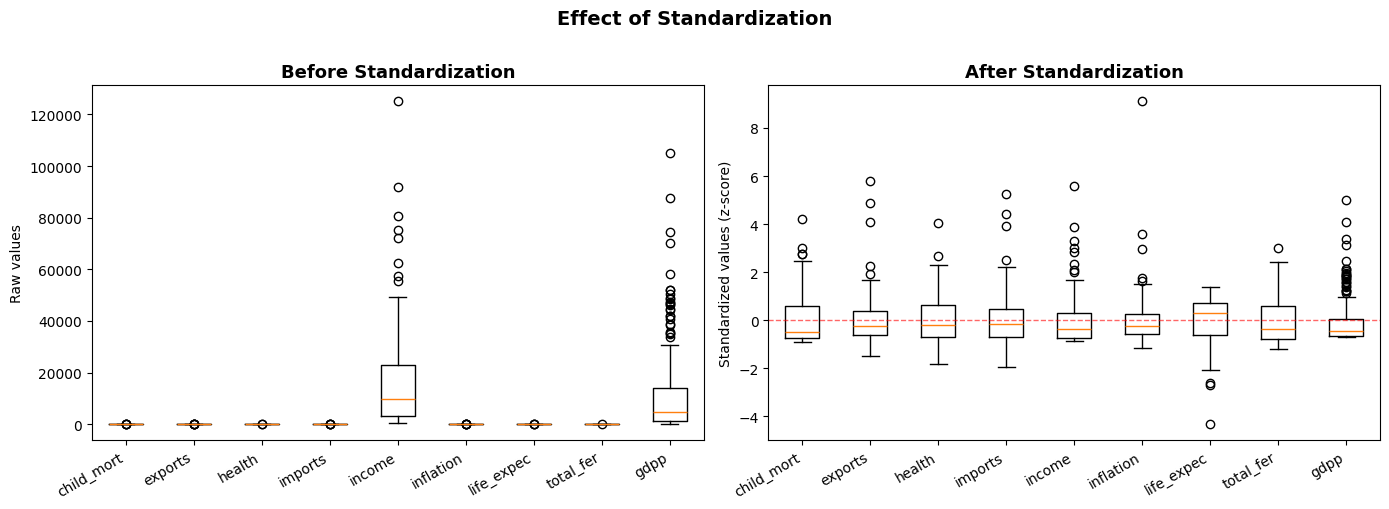

 All features are now on the same scale — PCA can proceed fairly.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before standardization
axes[0].boxplot(X_raw, tick_labels=feature_names, vert=True)
axes[0].set_title('Before Standardization', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(feature_names, rotation=30, ha='right')
axes[0].set_ylabel('Raw values')

# After standardization
axes[1].boxplot(X, tick_labels=feature_names, vert=True)
axes[1].set_title('After Standardization', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(feature_names, rotation=30, ha='right')
axes[1].set_ylabel('Standardized values (z-score)')
axes[1].axhline(0, color='red', lw=1, ls='--', alpha=0.6)

plt.suptitle('Effect of Standardization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(" All features are now on the same scale — PCA can proceed fairly.")

Computing the Covariance

In [ ]:
n = X.shape[0]          # number of samples = 167

# X.T  →  transpose of X, shape (9, 167)
# X.T @ X  →  matrix multiply → shape (9, 9)
# Divide by (n-1) for the unbiased sample covariance
C = (X.T @ X) / (n - 1)

print(f"Covariance matrix shape: {C.shape}")
print()
print("Diagonal values (variance of each standardized feature — should be ≈ 1.0):")
for name, v in zip(feature_names, np.diag(C)):
    print(f"  {name:<12}: {v:.6f}")

Covariance matrix shape: (9, 9)

Diagonal values (variance of each standardized feature — should be ≈ 1.0):
  child_mort  : 1.000000
  exports     : 1.000000
  health      : 1.000000
  imports     : 1.000000
  income      : 1.000000
  inflation   : 1.000000
  life_expec  : 1.000000
  total_fer   : 1.000000
  gdpp        : 1.000000


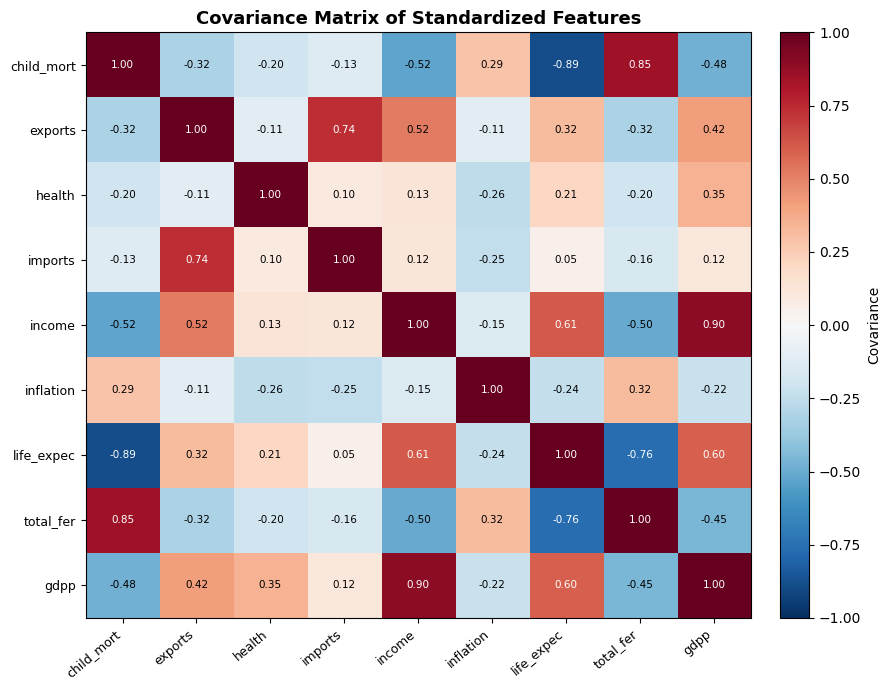


🔍 Observations:
  • child_mort & life_expec  → strong NEGATIVE covariance (high mortality = low life expectancy)
  • income & gdpp            → strong POSITIVE covariance (richer country = higher GDP per capita)
  • These correlations are what PCA will exploit to reduce dimensions.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

# imshow renders the matrix as a colour grid
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colour bar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Covariance', fontsize=10)

# Tick labels = feature names
ticks = np.arange(len(feature_names))
ax.set_xticks(ticks); ax.set_xticklabels(feature_names, rotation=40, ha='right', fontsize=9)
ax.set_yticks(ticks); ax.set_yticklabels(feature_names, fontsize=9)

# Print the numeric value inside each cell
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{C[i, j]:.2f}',
                ha='center', va='center', fontsize=7.5,
                color='white' if abs(C[i, j]) > 0.6 else 'black')

ax.set_title('Covariance Matrix of Standardized Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("🔍 Observations:")
print("  • child_mort & life_expec  → strong NEGATIVE covariance (high mortality = low life expectancy)")
print("  • income & gdpp            → strong POSITIVE covariance (richer country = higher GDP per capita)")
print("  • These correlations are what PCA will exploit to reduce dimensions.")

Eigen Decomposition


In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(C)

print(f"Eigenvalues shape  : {eigenvalues.shape}")
print(f"Eigenvectors shape : {eigenvectors.shape}")
print()
print("Raw eigenvalues (unsorted):")
print(np.round(eigenvalues, 4))

Eigenvalues shape  : (9,)
Eigenvectors shape : (9, 9)

Raw eigenvalues (unsorted):
[0.0669 0.0883 0.1134 0.2236 0.6606 0.9948 1.1704 1.5463 4.1357]


In [ ]:
sort_idx = np.argsort(eigenvalues)[::-1]

# Reorder both eigenvalues and eigenvectors using the sorted indices
eigenvalues  = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]    # columns, so index second axis

# Clip tiny negatives caused by floating-point rounding (should be ≥ 0)
eigenvalues = np.clip(eigenvalues, 0, None)

print("Sorted eigenvalues (largest → smallest):")
for i, lam in enumerate(eigenvalues):
    print(f"  λ{i+1} = {lam:.4f}")

Sorted eigenvalues (largest → smallest):
  λ1 = 4.1357
  λ2 = 1.5463
  λ3 = 1.1704
  λ4 = 0.9948
  λ5 = 0.6606
  λ6 = 0.2236
  λ7 = 0.1134
  λ8 = 0.0883
  λ9 = 0.0669


In [ ]:
total_variance          = eigenvalues.sum()
explained_var_ratio     = eigenvalues / total_variance
cumulative_var_ratio    = np.cumsum(explained_var_ratio)

print(f"Total variance (sum of all eigenvalues): {total_variance:.4f}")
print()
print(f"{'PC':<5} {'Eigenvalue':>12} {'Expl. Var %':>12} {'Cumulative %':>13}")
print("-" * 45)
for i, (lam, evr, cum) in enumerate(zip(eigenvalues, explained_var_ratio, cumulative_var_ratio)):
    print(f"PC{i+1:<3} {lam:>12.4f} {evr*100:>11.2f}% {cum*100:>12.2f}%")

Total variance (sum of all eigenvalues): 9.0000

PC      Eigenvalue  Expl. Var %  Cumulative %
---------------------------------------------
PC1         4.1357       45.95%        45.95%
PC2         1.5463       17.18%        63.13%
PC3         1.1704       13.00%        76.14%
PC4         0.9948       11.05%        87.19%
PC5         0.6606        7.34%        94.53%
PC6         0.2236        2.48%        97.02%
PC7         0.1134        1.26%        98.28%
PC8         0.0883        0.98%        99.26%
PC9         0.0669        0.74%       100.00%


In [ ]:
threshold = 0.95
# np.where returns indices where condition is True
# [0][0] gets the first (smallest) index where cumulative ≥ 95%
k_95 = int(np.where(cumulative_var_ratio >= threshold)[0][0]) + 1  # +1 because 0-indexed

print(f"Components needed to explain {threshold*100:.0f}% of variance: {k_95}")

Components needed to explain 95% of variance: 6


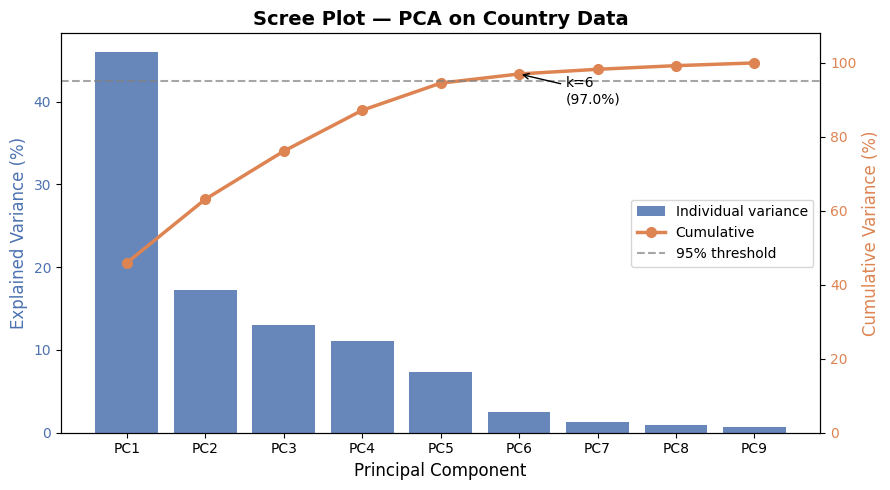


🔍 The elbow is clear after PC6.
   PC1 + PC2 alone explain 63.1% of variance.
   PC1 + PC2 + PC3 explain 76.1% of variance.


In [ ]:
p = len(eigenvalues)        # total number of features = 9
x = np.arange(1, p + 1)    # x-axis: PC1, PC2, ..., PC9

fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart → individual explained variance per PC
ax1.bar(x, explained_var_ratio * 100,
        color='#4C72B0', alpha=0.85, label='Individual variance')

# Mark the 95% threshold
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance (%)', fontsize=12, color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(x)
ax1.set_xticklabels([f'PC{i}' for i in x])

# Twin y-axis for the cumulative line
ax2 = ax1.twinx()
ax2.plot(x, cumulative_var_ratio * 100,
         'o-', color='#DD8452', lw=2.5, ms=7, label='Cumulative')
ax2.axhline(95, color='gray', ls='--', lw=1.5, alpha=0.7, label='95% threshold')
ax2.set_ylabel('Cumulative Variance (%)', fontsize=12, color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.set_ylim(0, 108)

# Annotate the elbow / threshold point
ax2.annotate(f'k={k_95}\n({cumulative_var_ratio[k_95-1]*100:.1f}%)',
             xy=(k_95, cumulative_var_ratio[k_95-1] * 100),
             xytext=(k_95 + 0.6, cumulative_var_ratio[k_95-1] * 100 - 8),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

plt.title('Scree Plot — PCA on Country Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n🔍 The elbow is clear after PC{k_95}.")
print(f"   PC1 + PC2 alone explain {cumulative_var_ratio[1]*100:.1f}% of variance.")
print(f"   PC1 + PC2 + PC3 explain {cumulative_var_ratio[2]*100:.1f}% of variance.")

Select Top K components Loading matrix

In [ ]:
k = 2      # we'll project to 2-D for visualization

# eigenvectors has shape (9, 9) — each COLUMN is one eigenvector
# We want the first k columns → then transpose to get shape (k, 9)
W_k = eigenvectors[:, :k].T    # shape: (k=2, p=9)

print(f"Loading matrix W_k shape: {W_k.shape}   → ({k} components × {W_k.shape[1]} features)")

Loading matrix W_k shape: (2, 9)   → (2 components × 9 features)


In [ ]:
loadings_df = pd.DataFrame(
    W_k,
    index=[f'PC{i+1}' for i in range(k)],
    columns=feature_names
)

print("Loading matrix (how much each feature contributes to each PC):")
print(loadings_df.round(4).to_string())
print()
print("Interpretation guide:")
print("  Positive loading → feature moves in the SAME direction as the PC")
print("  Negative loading → feature moves in the OPPOSITE direction")
print("  |value| close to 1.0 → strong contribution")
print("  |value| close to 0.0 → weak contribution")

Loading matrix (how much each feature contributes to each PC):
     child_mort  exports  health  imports  income  inflation  life_expec  total_fer    gdpp
PC1     -0.4195   0.2839  0.1508   0.1615  0.3984    -0.1932      0.4258    -0.4037  0.3926
PC2      0.1929   0.6132 -0.2431   0.6718  0.0225    -0.0084     -0.2227     0.1552 -0.0460

Interpretation guide:
  Positive loading → feature moves in the SAME direction as the PC
  Negative loading → feature moves in the OPPOSITE direction
  |value| close to 1.0 → strong contribution
  |value| close to 0.0 → weak contribution


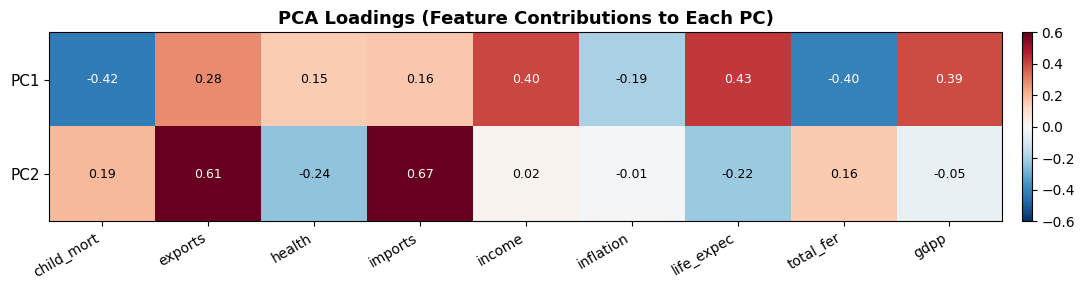

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))

im = ax.imshow(W_k, cmap='RdBu_r', aspect='auto', vmin=-0.6, vmax=0.6)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(k))
ax.set_yticklabels([f'PC{i+1}' for i in range(k)], fontsize=11)

for i in range(k):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{W_k[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='white' if abs(W_k[i, j]) > 0.35 else 'black')

ax.set_title('PCA Loadings (Feature Contributions to Each PC)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Project Data onto Principal Componnets

In [ ]:
Z = X @ W_k.T

print(f"Original X shape  : {X.shape}   (167 countries × 9 features)")
print(f"Projection Z shape: {Z.shape}  (167 countries × 2 principal components)")
print()
print("First 5 country projections:")
for i in range(5):
    print(f"  {country_names[i]:<25}  PC1={Z[i,0]:>7.3f}   PC2={Z[i,1]:>7.3f}")

Original X shape  : (167, 9)   (167 countries × 9 features)
Projection Z shape: (167, 2)  (167 countries × 2 principal components)

First 5 country projections:
  Afghanistan                PC1= -2.904   PC2=  0.095
  Albania                    PC1=  0.429   PC2= -0.586
  Algeria                    PC1= -0.284   PC2= -0.454
  Angola                     PC1= -2.924   PC2=  1.690
  Antigua and Barbuda        PC1=  1.030   PC2=  0.136


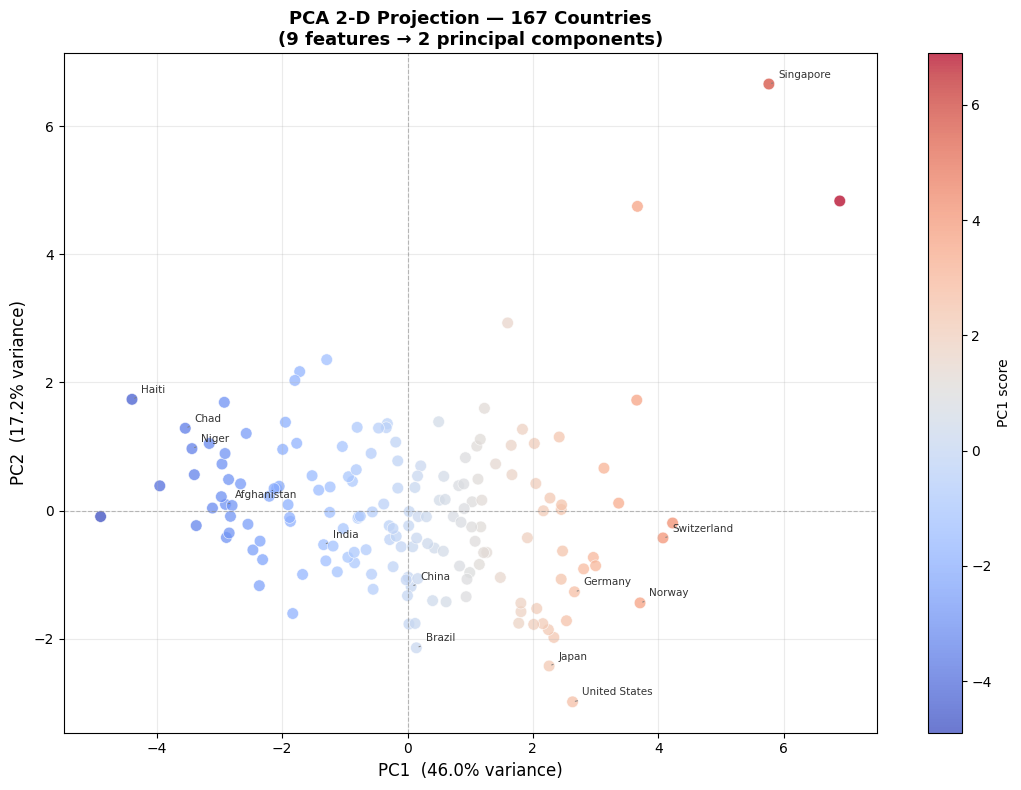


🔍 Observations from the plot:
  • Countries on the LEFT of PC1 tend to be DEVELOPED nations (high income, high life expectancy)
  • Countries on the RIGHT tend to be DEVELOPING nations (high child mortality, high fertility)
  • PC2 separates by economic openness (exports/imports vs inflation patterns)


In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(Z[:, 0], Z[:, 1],
                     s=70, alpha=0.75, edgecolors='white', lw=0.5,
                     c=Z[:, 0], cmap='coolwarm')   # colour by PC1 score

plt.colorbar(scatter, ax=ax, label='PC1 score')

# Annotate a selection of interesting countries
highlight = [
    'United States', 'China', 'India', 'Niger', 'Afghanistan',
    'Norway', 'Japan', 'Brazil', 'Germany', 'Somalia',
    'Singapore', 'Haiti', 'Switzerland', 'Chad'
]
for i, name in enumerate(country_names):
    if name in highlight:
        ax.annotate(name, xy=(Z[i, 0], Z[i, 1]),
                    xytext=(Z[i, 0] + 0.15, Z[i, 1] + 0.1),
                    fontsize=7.5, color='#333333',
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.7))

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel(f'PC1  ({explained_var_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({explained_var_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2-D Projection — 167 Countries\n(9 features → 2 principal components)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print()
print("🔍 Observations from the plot:")
print("  • Countries on the LEFT of PC1 tend to be DEVELOPED nations (high income, high life expectancy)")
print("  • Countries on the RIGHT tend to be DEVELOPING nations (high child mortality, high fertility)")
print("  • PC2 separates by economic openness (exports/imports vs inflation patterns)")

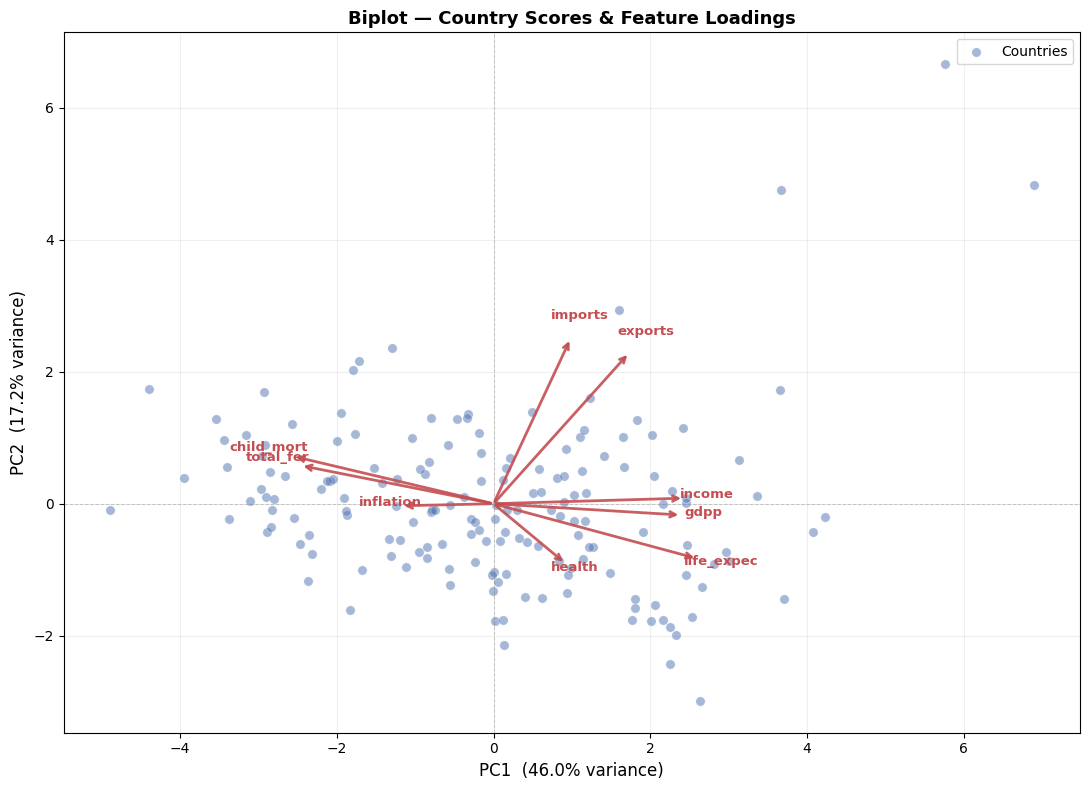


🔍 Reading the arrows:
  • child_mort & total_fer point RIGHT → positive PC1 → developing countries
  • life_expec, income, gdpp point LEFT → negative PC1 → developed countries
  • health & exports point UPWARD → positive PC2 influence


In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

# Plot country scores
ax.scatter(Z[:, 0], Z[:, 1],
           s=45, alpha=0.5, color='#4C72B0', edgecolors='white', lw=0.4,
           label='Countries', zorder=2)

# Scale factor for the loading arrows
scale_x = np.sqrt(eigenvalues[0]) * 3.0
scale_y = np.sqrt(eigenvalues[1]) * 3.0

# Draw one arrow per feature
for j, fname in enumerate(feature_names):
    lx = W_k[0, j] * scale_x     # x-tip of the arrow (PC1 loading × scale)
    ly = W_k[1, j] * scale_y     # y-tip of the arrow (PC2 loading × scale)

    # Draw the arrow
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#C44E52',
                                lw=2.0, alpha=0.9))

    # Label the arrow tip
    ax.text(lx * 1.12, ly * 1.12, fname,
            color='#C44E52', fontsize=9.5, fontweight='bold', ha='center')

# Reference lines through origin
ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.4)
ax.axvline(0, color='gray', lw=0.7, ls='--', alpha=0.4)

ax.set_xlabel(f'PC1  ({explained_var_ratio[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2  ({explained_var_ratio[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Biplot — Country Scores & Feature Loadings', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print()
print("🔍 Reading the arrows:")
print("  • child_mort & total_fer point RIGHT → positive PC1 → developing countries")
print("  • life_expec, income, gdpp point LEFT → negative PC1 → developed countries")
print("  • health & exports point UPWARD → positive PC2 influence")

In [ ]:
X_approx_std = Z @ W_k      # (167, 2) @ (2, 9) = (167, 9)

# Un-standardize: multiply back by std, add back the mean
X_reconstructed = X_approx_std * std + mean

print(f"Z (compressed) shape  : {Z.shape}")
print(f"X_reconstructed shape : {X_reconstructed.shape}")

Z (compressed) shape  : (167, 2)
X_reconstructed shape : (167, 9)


In [ ]:
mse_list = []

for k_test in range(1, 10):                        # try each possible k
    W_test   = eigenvectors[:, :k_test].T          # loading matrix shape (k_test, 9)
    Z_test   = X @ W_test.T                        # project    shape (n, k_test)
    X_approx = Z_test @ W_test                     # reconstruct shape (n, 9)
    X_hat    = X_approx * std + mean               # un-standardize
    mse      = np.mean((X_raw - X_hat) ** 2)       # mean squared error
    mse_list.append(mse)
    print(f"  k={k_test}  MSE={mse:>12.4f}   Variance explained: {cumulative_var_ratio[k_test-1]*100:.1f}%")

  k=1  MSE=27543750.3745   Variance explained: 46.0%
  k=2  MSE=27389888.7120   Variance explained: 63.1%
  k=3  MSE=22364802.8725   Variance explained: 76.1%
  k=4  MSE=5639065.1310   Variance explained: 87.2%
  k=5  MSE=3187091.5012   Variance explained: 94.5%
  k=6  MSE=2948796.6245   Variance explained: 97.0%
  k=7  MSE=2657737.5586   Variance explained: 98.3%
  k=8  MSE=2002678.0734   Variance explained: 99.3%
  k=9  MSE=      0.0000   Variance explained: 100.0%


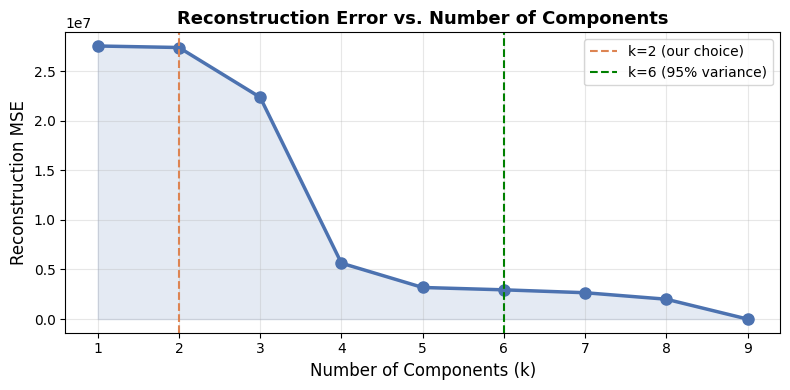

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(1, 10), mse_list, 'o-', color='#4C72B0', lw=2.5, ms=8)
ax.fill_between(range(1, 10), mse_list, alpha=0.15, color='#4C72B0')
ax.axvline(2, color='#DD8452', ls='--', lw=1.5, label='k=2 (our choice)')
ax.axvline(k_95, color='green', ls='--', lw=1.5, label=f'k={k_95} (95% variance)')

ax.set_xlabel('Number of Components (k)', fontsize=12)
ax.set_ylabel('Reconstruction MSE', fontsize=12)
ax.set_title('Reconstruction Error vs. Number of Components', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, 10))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

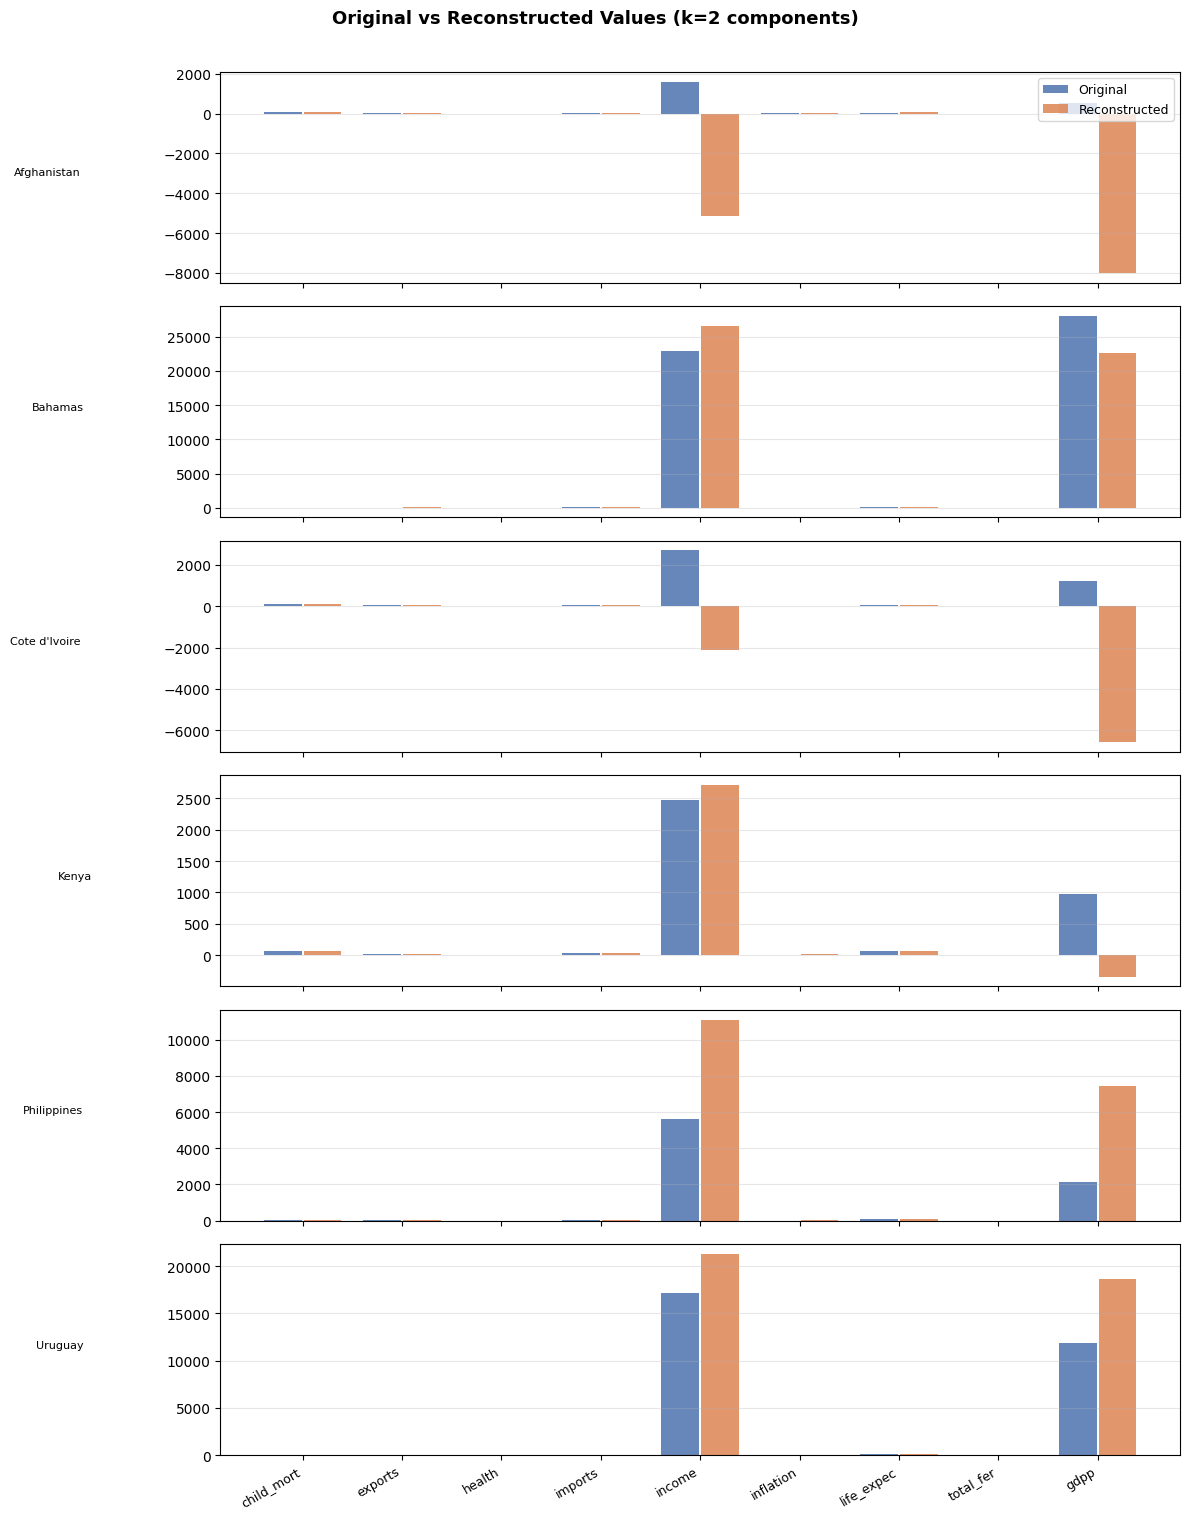

In [ ]:
sample_idx = [0, 10, 40, 80, 120, 160]    # pick 6 countries spread across the dataset
n_show = len(sample_idx)
x_pos = np.arange(len(feature_names))

fig, axes = plt.subplots(n_show, 1, figsize=(12, 2.5 * n_show), sharex=True)

for ax, i in zip(axes, sample_idx):
    bars1 = ax.bar(x_pos - 0.2, X_raw[i],            0.38,
                   label='Original',      color='#4C72B0', alpha=0.85)
    bars2 = ax.bar(x_pos + 0.2, X_reconstructed[i],  0.38,
                   label='Reconstructed', color='#DD8452', alpha=0.85)
    ax.set_ylabel(country_names[i], fontsize=8, rotation=0, ha='right', labelpad=60)
    ax.grid(axis='y', alpha=0.3)
    if i == sample_idx[0]:
        ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xticks(x_pos)
axes[-1].set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
fig.suptitle('Original vs Reconstructed Values (k=2 components)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

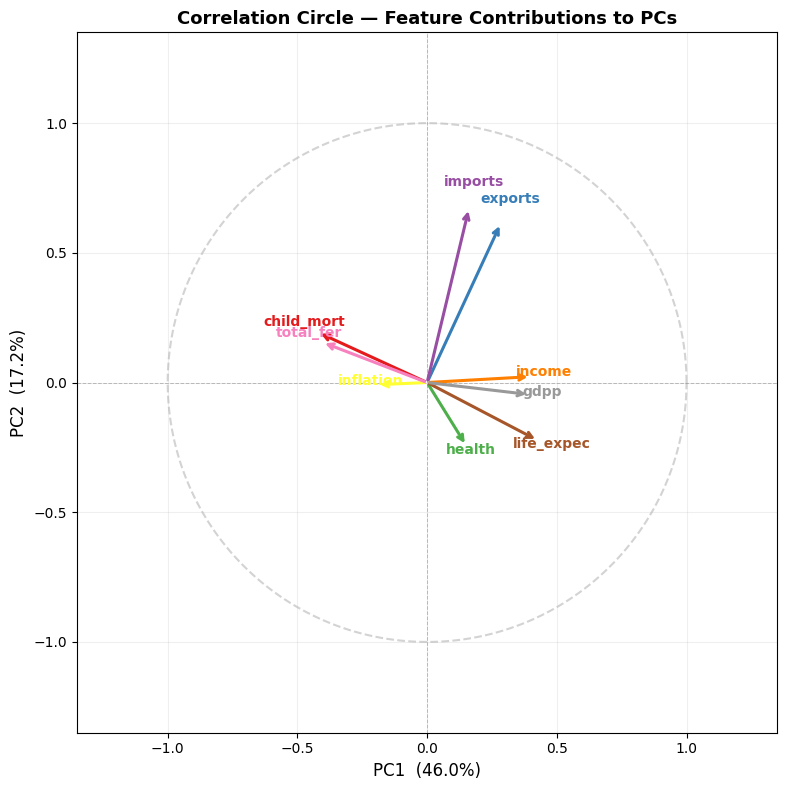


🔍 Observations:
  • life_expec & income/gdpp cluster together → developed-country indicators
  • child_mort & total_fer point OPPOSITE to life_expec → developing-country indicators
  • This confirms PC1 is a 'development axis'


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

# Draw the unit reference circle
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta),
        color='lightgray', lw=1.5, ls='--', zorder=0)

# Each feature = one arrow from origin to (W_k[0,j], W_k[1,j])
colors_list = plt.cm.Set1(np.linspace(0, 0.9, len(feature_names)))

for j, (fname, color) in enumerate(zip(feature_names, colors_list)):
    lx = W_k[0, j]   # PC1 loading = x-coordinate on the circle
    ly = W_k[1, j]   # PC2 loading = y-coordinate on the circle

    # Arrow from (0,0) to (lx, ly)
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))

    # Label slightly beyond the arrow tip
    ax.text(lx * 1.13, ly * 1.13, fname,
            color=color, fontsize=10, fontweight='bold', ha='center')

# Reference lines
ax.axhline(0, color='gray', lw=0.7, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.7, ls='--', alpha=0.5)

ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.set_xlabel(f'PC1  ({explained_var_ratio[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2  ({explained_var_ratio[1]*100:.1f}%)', fontsize=12)
ax.set_title('Correlation Circle — Feature Contributions to PCs', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print()
print("🔍 Observations:")
print("  • life_expec & income/gdpp cluster together → developed-country indicators")
print("  • child_mort & total_fer point OPPOSITE to life_expec → developing-country indicators")
print("  • This confirms PC1 is a 'development axis'")

## Custom PCA Class Implementation

Below is a custom implementation of PCA (Principal Component Analysis) from scratch using NumPy. This class encapsulates the entire PCA workflow, including standardization, covariance matrix calculation, eigen decomposition, and the ability to transform data into the principal component space and reconstruct it back. It provides methods for fitting the model (`fit`), transforming data (`transform`), combining both (`fit_transform`), and inverting the transformation (`inverse_transform`), along with calculating reconstruction error.

In [ ]:
class PCA:
    """
    PCA from scratch using only NumPy.
    Each method = one mathematical step.
    """

    def __init__(self, n_components=None, standardize=True):
        self.n_components = n_components   # k: how many PCs to keep
        self.standardize  = standardize    # whether to divide by std

        # These are set when fit() is called
        self.mean_         = None    # μ  shape (p,)
        self.std_          = None    # σ  shape (p,)
        self.cov_matrix_   = None    # C  shape (p, p)
        self.eigenvalues_  = None    # λ  shape (p,)
        self.eigenvectors_ = None    # V  shape (p, p)
        self.components_   = None    # W_k shape (k, p)
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """Learn principal components from data X."""
        X = np.array(X, dtype=float)
        n, p = X.shape
        k = p if self.n_components is None else self.n_components

        # Step 1: Standardize
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0, ddof=1)
        X_std = (X - self.mean_) / np.where(self.std_ == 0, 1, self.std_)

        # Step 2: Covariance matrix
        self.cov_matrix_ = (X_std.T @ X_std) / (n - 1)

        # Step 3: Eigen decomposition
        eigvals, eigvecs = np.linalg.eigh(self.cov_matrix_)

        # Step 4: Sort descending
        idx = np.argsort(eigvals)[::-1]
        self.eigenvalues_  = np.clip(eigvals[idx], 0, None)
        self.eigenvectors_ = eigvecs[:, idx]

        # Step 5: Select top-k
        self.components_ = self.eigenvectors_[:, :k].T    # shape (k, p)
        total = self.eigenvalues_.sum()
        self.explained_variance_ratio_ = self.eigenvalues_[:k] / (total or 1)
        return self

    def transform(self, X):
        """Project X into the k-dimensional PC space.  Z = X̃ · Wₖᵀ"""
        X_std = (X - self.mean_) / np.where(self.std_ == 0, 1, self.std_)
        return X_std @ self.components_.T           # shape (n, k)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        """Reconstruct original space.  X̂ = Z · Wₖ  (then un-standardize)"""
        X_approx = Z @ self.components_             # shape (n, p)
        return X_approx * self.std_ + self.mean_

    def reconstruction_error(self, X):
        """MSE = (1/n·p) · ||X - X̂||²"""
        Z = self.transform(X)
        X_hat = self.inverse_transform(Z)
        return float(np.mean((X - X_hat) ** 2))

In [ ]:
# Quick test with the custom PCA class

pca = PCA(n_components=2)
Z_out = pca.fit_transform(X_raw)

print("PCA class — quick test")
print(f"  Input shape   : {X_raw.shape}")
print(f"  Output shape  : {Z_out.shape}")
print(f"  Explained var : {np.round(pca.explained_variance_ratio_ * 100, 2)} %")
print(f"  MSE (k=2)     : {pca.reconstruction_error(X_raw):.4f}")
print("\n✅ PCA class works correctly!")

PCA class — quick test
  Input shape   : (167, 9)
  Output shape  : (167, 2)
  Explained var : [45.95 17.18] %
  MSE (k=2)     : 27389888.7120

✅ PCA class works correctly!


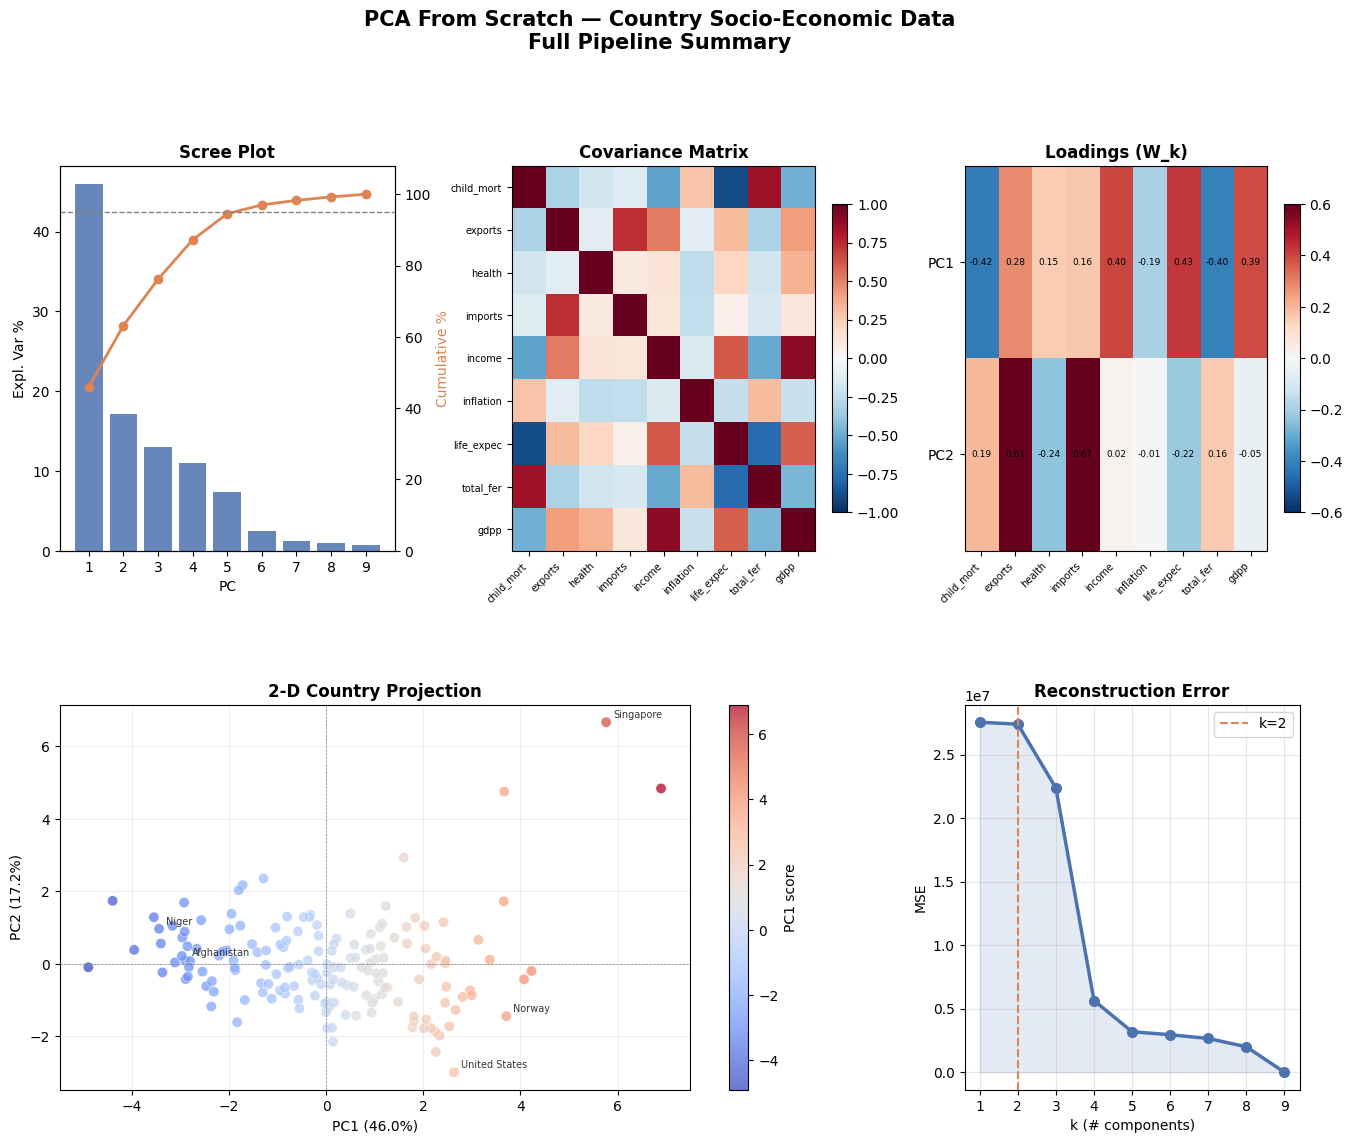


FINAL SUMMARY
  Countries (samples)  : 167
  Features             : 9
  PC1 variance         : 46.0%
  PC1+PC2 variance     : 63.1%
  Components for 95%%   : 6
  MSE with k=2         : 27389888.7120


In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

p_feat = len(feature_names)

# ── Panel 1: Scree plot ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(1, p_feat+1), explained_var_ratio * 100, color='#4C72B0', alpha=0.85)
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xlabel('PC'); ax1.set_ylabel('Expl. Var %')
ax1.set_xticks(range(1, p_feat+1))
ax1_t = ax1.twinx()
ax1_t.plot(range(1, p_feat+1), cumulative_var_ratio * 100, 'o-', color='#DD8452', lw=2)
ax1_t.axhline(95, color='gray', ls='--', lw=1)
ax1_t.set_ylabel('Cumulative %', color='#DD8452')
ax1_t.set_ylim(0, 108)

# ── Panel 2: Covariance heatmap ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(p_feat)); ax2.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
ax2.set_yticks(range(p_feat)); ax2.set_yticklabels(feature_names, fontsize=7)
ax2.set_title('Covariance Matrix', fontweight='bold')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# ── Panel 3: Loadings heatmap ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(W_k, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')
ax3.set_xticks(range(p_feat)); ax3.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['PC1', 'PC2'], fontsize=10)
ax3.set_title('Loadings (W_k)', fontweight='bold')
plt.colorbar(im3, ax=ax3, fraction=0.046)
for i in range(2):
    for j in range(p_feat):
        ax3.text(j, i, f'{W_k[i,j]:.2f}', ha='center', va='center', fontsize=6.5)

# ── Panel 4: 2-D scatter ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
sc = ax4.scatter(Z[:, 0], Z[:, 1], c=Z[:, 0], cmap='coolwarm',
                  s=55, alpha=0.75, edgecolors='white', lw=0.4)
plt.colorbar(sc, ax=ax4, label='PC1 score')
for i, name in enumerate(country_names):
    if name in ['United States', 'Niger', 'Norway', 'Afghanistan', 'Singapore', 'Somalia']:
        ax4.annotate(name, (Z[i,0], Z[i,1]), fontsize=7, xytext=(5,3),
                     textcoords='offset points', color='#333333')
ax4.set_xlabel(f'PC1 ({explained_var_ratio[0]*100:.1f}%)')
ax4.set_ylabel(f'PC2 ({explained_var_ratio[1]*100:.1f}%)')
ax4.set_title('2-D Country Projection', fontweight='bold')
ax4.axhline(0, color='gray', lw=0.5, ls='--'); ax4.axvline(0, color='gray', lw=0.5, ls='--')
ax4.grid(True, alpha=0.2)

# ── Panel 5: Reconstruction error ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(range(1, p_feat+1), mse_list, 'o-', color='#4C72B0', lw=2.5, ms=7)
ax5.fill_between(range(1, p_feat+1), mse_list, alpha=0.15, color='#4C72B0')
ax5.axvline(2, color='#DD8452', ls='--', lw=1.5, label='k=2')
ax5.set_xlabel('k (# components)'); ax5.set_ylabel('MSE')
ax5.set_title('Reconstruction Error', fontweight='bold')
ax5.set_xticks(range(1, p_feat+1)); ax5.legend(); ax5.grid(True, alpha=0.3)

fig.suptitle('PCA From Scratch — Country Socio-Economic Data\nFull Pipeline Summary',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Countries (samples)  : 167")
print(f"  Features             : 9")
print(f"  PC1 variance         : {explained_var_ratio[0]*100:.1f}%")
print(f"  PC1+PC2 variance     : {cumulative_var_ratio[1]*100:.1f}%")
print(f"  Components for 95%%   : {k_95}")
print(f"  MSE with k=2         : {mse_list[1]:.4f}")
print("="*60)